# Deepfake Landmark Retrieval — Evaluation
This notebook evaluates the new **retrieval-based** landmark detection system using **DINOv2 embeddings** and a **FAISS** index.

### Workflow:
1. **Load Index**: Initialize the `LandmarkIndex` with the pre-built FAISS database.
2. **Evaluation**: Benchmark the retrieval accuracy on the `zguo0525/google-landmarks-v2-mini` test split.
3. **Visualization**: Display input images alongside their top-K retrieved landmark matches.
4. **Pipeline Test**: Run the full `DeepfakeClassifier` (Face + Scene + Landmark) on sample images.

> ⚠️ **Pre-requisite:** Ensure you have run `python initialize_index.py` to build the FAISS index in the `models/` directory.

## 0. Setup and Imports

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from datasets import load_dataset
from sklearn.metrics import classification_report, accuracy_score

from deepfake_classifier import DeepfakeClassifier, LandmarkIndex

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

W0508 16:21:28.573000 66429 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Using device: mps


## 1. Load Landmark Index and Dataset

In [2]:
# 1. Initialize the Landmark Index
index_path = 'models/landmarks_index.faiss'
metadata_path = 'models/landmarks_metadata.json'

if not os.path.exists(index_path):
    raise FileNotFoundError(f"Index not found at {index_path}. Please run initialize_index.py first.")

landmark_index = LandmarkIndex(
    model_name='facebook/dinov2-base',
    index_path=index_path,
    metadata_path=metadata_path,
    device=device
)

# 2. Load the test dataset
print("Loading Google Landmarks Mini test split...")
dataset = load_dataset('zguo0525/google-landmarks-v2-mini')
test_ds = dataset['test']
label_names = dataset['train'].features['label'].names
print(f"Loaded {len(test_ds)} test samples.")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading FAISS index from models/landmarks_index.faiss...
Landmark index loaded successfully.
Loading Google Landmarks Mini test split...
Loaded 6206 test samples.


## 2. Benchmark Retrieval Accuracy
We query the index for each test image and check if the ground truth label matches the best candidate.

In [3]:
# Set a subset for faster evaluation if needed
num_samples = min(500, len(test_ds)) 
y_true = []
y_pred = []

print(f"Evaluating retrieval on {num_samples} samples...")
for i in tqdm(range(num_samples)):
    item = test_ds[i]
    img = item['image'].convert('RGB')
    true_label = label_names[item['label']]
    
    # Query the index
    result = landmark_index.search(img, top_k=10, similarity_threshold=0.4)
    
    y_true.append(true_label)
    y_pred.append(result['label'])

acc = accuracy_score(y_true, y_pred)
print(f"\nTop-1 Retrieval Accuracy: {acc:.4f}")
print("\nClassification Report (Top 10 classes):")
unique_labels = sorted(list(set(y_true)))
print(classification_report(y_true, y_pred, labels=unique_labels[:10], zero_division=0))

Evaluating retrieval on 500 samples...


  0%|          | 0/500 [00:00<?, ?it/s]


Top-1 Retrieval Accuracy: 0.6940

Classification Report (Top 10 classes):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         1
          10       0.00      0.00      0.00         1
         100       1.00      1.00      1.00         1
         101       1.00      1.00      1.00         1
         102       1.00      1.00      1.00         1
         103       1.00      1.00      1.00         1
         104       1.00      1.00      1.00         1
         105       0.00      0.00      0.00         1
         106       1.00      1.00      1.00         1

   micro avg       0.88      0.70      0.78        10
   macro avg       0.70      0.70      0.70        10
weighted avg       0.70      0.70      0.70        10



## 3. Visualize Retrieval Results
Let's see the matches retrieved for a single sample.

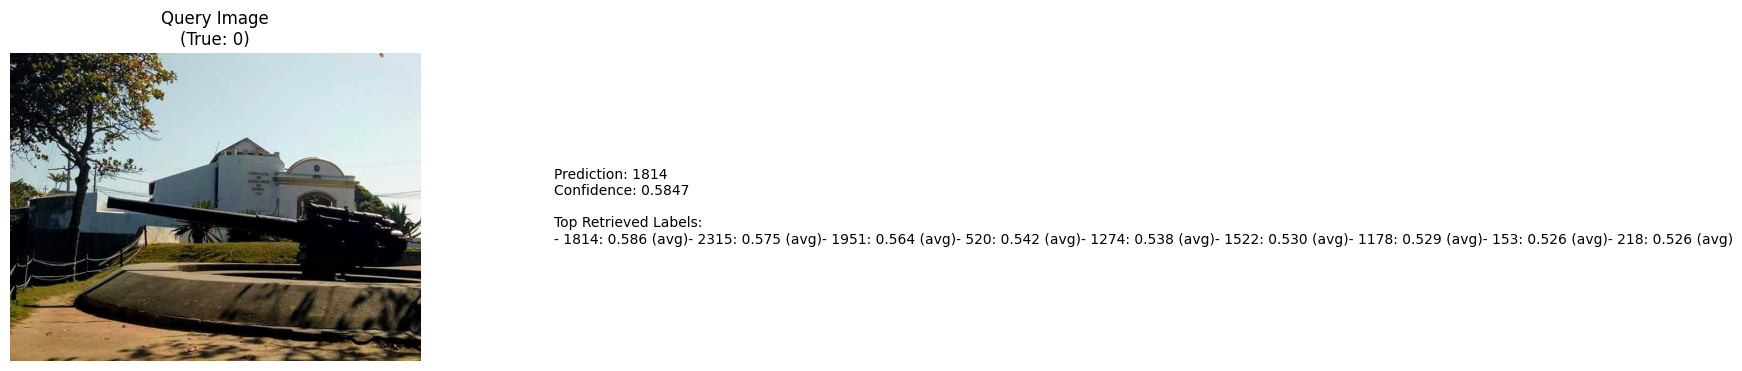

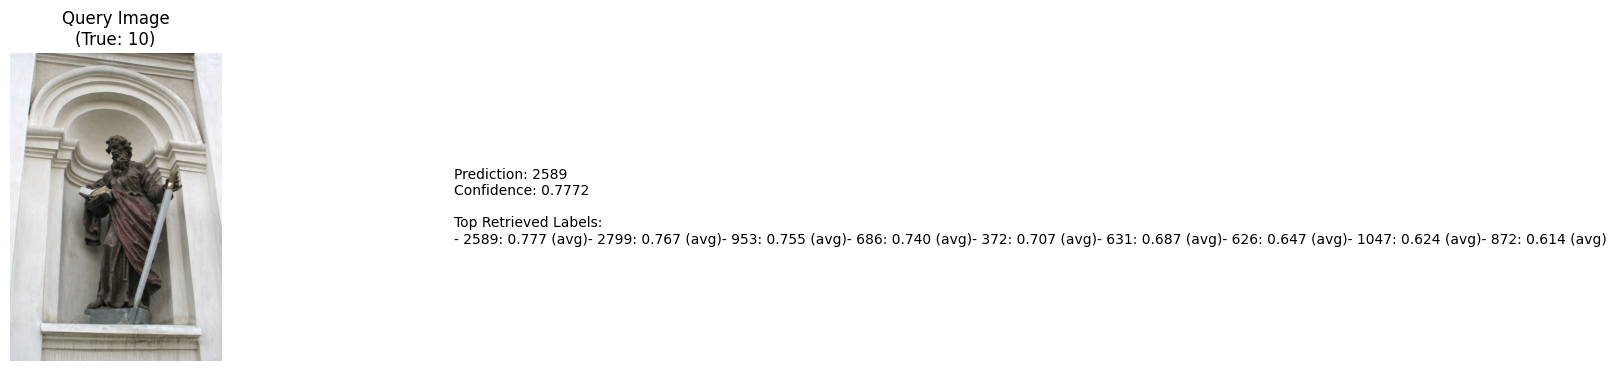

In [4]:
def visualize_retrieval(sample_idx):
    item = test_ds[sample_idx]
    img = item['image'].convert('RGB')
    true_label = label_names[item['label']]
    
    result = landmark_index.search(img, top_k=10)
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Query Image\n(True: {true_label})")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    matches = result.get('all_matches', {})
    match_text = "Top Retrieved Labels:\n"
    for label, scores in sorted(matches.items(), key=lambda x: max(x[1]), reverse=True):
        match_text += f"- {label}: {max(scores):.3f} (avg)"
    
    plt.text(0.1, 0.5, f"Prediction: {result['label']}\nConfidence: {result['confidence']}\n\n{match_text}", 
             fontsize=10, verticalalignment='center')
    plt.axis('off')
    plt.show()

visualize_retrieval(0)
visualize_retrieval(10)

## 4. Full Deepfake Pipeline Test
Integrating the retrieval system into the `DeepfakeClassifier`.

In [7]:
classifier = DeepfakeClassifier(
    index_path=index_path,
    metadata_path=metadata_path
)

sample_item = test_ds[50]
sample_img = sample_item['image']

print("Running full pipeline inference...")
results = classifier.predict(sample_img)

import json
print(json.dumps(results, indent=2))

Loading Face Forensics model: prithivMLmods/deepfake-detector-model-v1


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Loading Scene model: birder-project/rope_vit_reg4_b14_capi-places365


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading Landmark Retrieval model: facebook/dinov2-base


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading FAISS index from models/landmarks_index.faiss...
Landmark index loaded successfully.
Running full pipeline inference...
{
  "visual_classification": null,
  "deepfake_analysis": {
    "deepfake_confidence": 0.7066,
    "face_analysis": {
      "label": "Fake",
      "confidence": 0.7066,
      "probs": [
        0.7065593004226685,
        0.2934407591819763
      ]
    },
    "scene_analysis": {
      "label": "vault",
      "confidence": 0.9695
    },
    "landmark_analysis": {
      "label": "1341",
      "confidence": 0.5923,
      "matches_count": 2,
      "all_matches": {
        "1341": [
          0.620862603187561,
          0.563698410987854
        ],
        "147": [
          0.5542382001876831
        ],
        "2033": [
          0.5504981279373169
        ],
        "2928": [
          0.5464383363723755
        ],
        "2845": [
          0.5326581001281738,
          0.5241733193397522
        ],
        "438": [
          0.520459771156311
        ],
    